### -InvoiceNo: Unique identifier for each transaction
### -StockCode: Product code
### -Description: Product name
### -Quantity: Number of items purchased
### -InvoiceDate: Date and time of the transaction
### -UnitPrice: Price per unit of the product
### -CustomerID: Unique identifier for each customer
### -Country: Country where the transaction occurred

## Step 1: Importing Libraries

In [1]:
# Data handling
import pandas as pd 
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Step 2: Loading the dataset

In [2]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12-09-2011 12:50,4.95,12680.0,France


## Step 3: Data Understand

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.shape

(541909, 8)

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Step 4: Data Cleaning

In [9]:
df = df.dropna()

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

In [11]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [12]:
df.shape

(397884, 8)

## Feature Engineering (RFM)

### Create Revenue Column

In [13]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Calculate RFM

In [14]:
reference_date = df['InvoiceDate'].max() + timedelta(days=1)

In [15]:
reference_date

Timestamp('2011-12-10 12:50:00')

In [16]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x : (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum',
})
rfm.head()

,InvoiceDate,InvoiceNo,TotalAmount
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [17]:
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalAmount': 'Monetary',}, inplace=True)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## Step 4: Exploratory Data Analysis

## Outliers_Treatment 

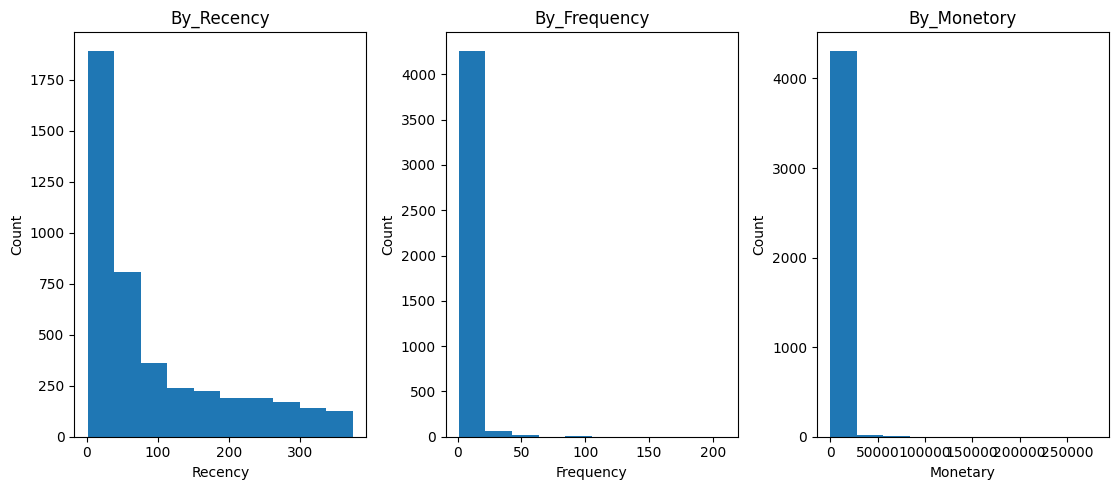

In [18]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.hist(rfm['Recency'])         
plt.xlabel('Recency')
plt.ylabel('Count')
plt.title('By_Recency')

plt.subplot(1,4,2)
plt.hist(rfm['Frequency'])     
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.title('By_Frequency')

plt.subplot(1,4,3)
plt.hist(rfm['Monetary'])         
plt.xlabel('Monetary')
plt.ylabel('Count')
plt.title('By_Monetory')
plt.tight_layout()
plt.show()

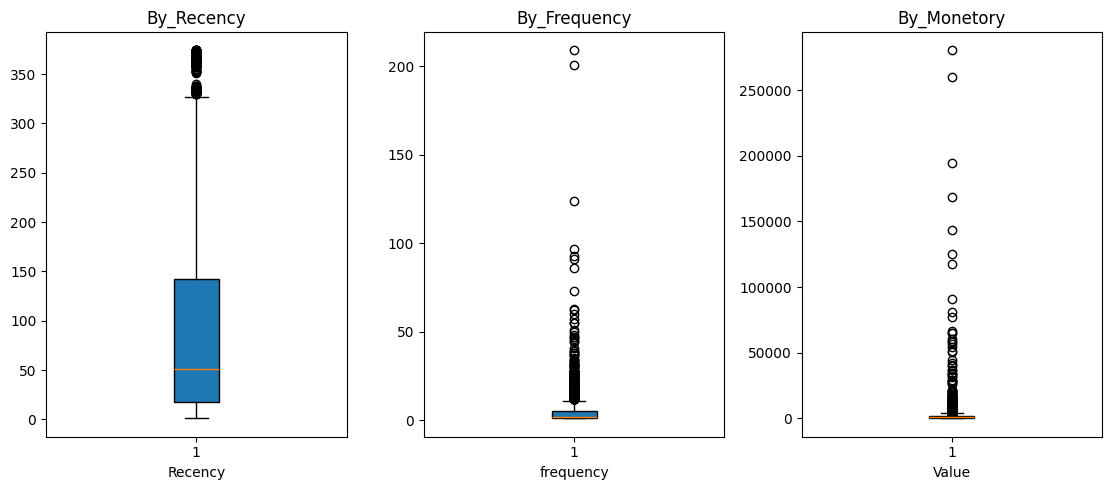

In [19]:
plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.boxplot(rfm['Recency'],  patch_artist=True)        
plt.xlabel('Recency')
plt.title('By_Recency')

plt.subplot(1,4,2)
plt.boxplot(rfm['Frequency'],  patch_artist=True)       
plt.xlabel('frequency')
plt.title('By_Frequency')

plt.subplot(1,4,3)
plt.boxplot(rfm['Monetary'],  patch_artist=True)         
plt.xlabel('Value')
plt.title('By_Monetory')

plt.tight_layout()
plt.show()

## Handling Outliers

### Removing Outliers

In [20]:
# Removing (Statistical) outliers for Monetary
Q1 = rfm["Monetary"].quantile(0.05)
Q3 = rfm["Monetary"].quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm["Monetary"] >= Q1 - 1.5 * IQR) & (rfm["Monetary"] <= Q3 + 1.5 * IQR)]

# Removing (Statistical) outliers for Recency
Q1 = rfm["Recency"].quantile(0.05)
Q3 = rfm["Recency"].quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm["Recency"] >= Q1 - 1.5 * IQR) & (rfm["Recency"] <= Q3 + 1.5 * IQR)]

# Removing (Statistical) outliers for Frequency
Q1 = rfm["Frequency"].quantile(0.05)
Q3 = rfm["Frequency"].quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm["Frequency"] >= Q1 - 1.5 * IQR) & (rfm["Frequency"] <= Q3 + 1.5 * IQR)]

rfm.shape

(4261, 3)

## Clustering Data

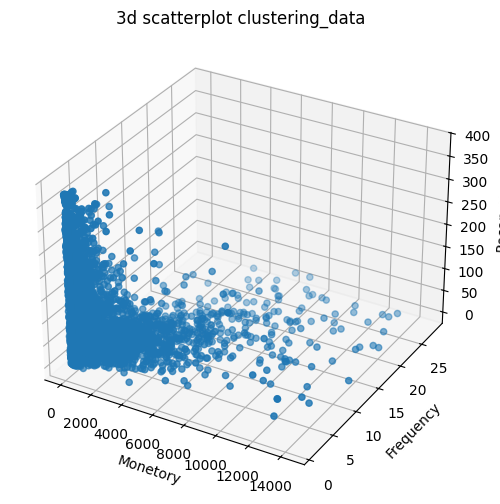

In [21]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(rfm['Monetary'],rfm['Frequency'],rfm['Recency'])
ax.set_xlabel('Monetory')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recancy')
ax.set_title('3d scatterplot clustering_data')
plt.show()

## Correlation Heatmap

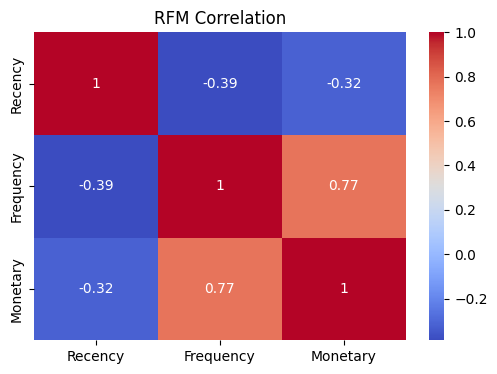

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')
plt.title("RFM Correlation")
plt.show()

## Feature Scaling

In [23]:
rfm = rfm[['Monetary', 'Frequency', 'Recency']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Monetary','Frequency','Recency'])
rfm_scaled.shape

(4261, 3)

## K-Means Clustering

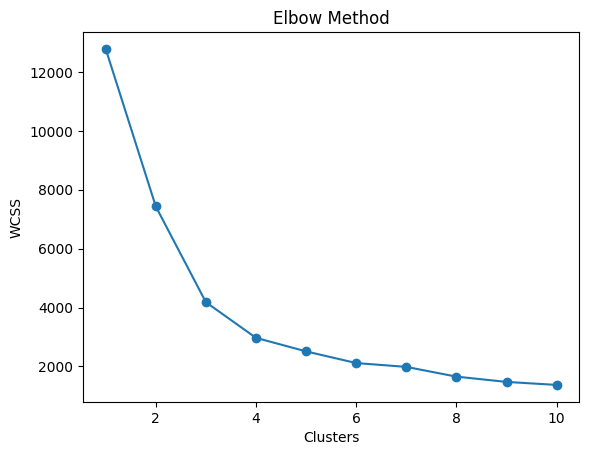

In [24]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(rfm_scaled)

### Silhouette Score

In [28]:
range_n_clusters = list(range(2, 12))
silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(rfm_scaled)

    silhouette_avg = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"For n_clusters = {n_clusters}, the average silhouette_score is {silhouette_avg:.4f}")

For n_clusters = 2, the average silhouette_score is 0.5509
For n_clusters = 3, the average silhouette_score is 0.5110
For n_clusters = 4, the average silhouette_score is 0.4871
For n_clusters = 5, the average silhouette_score is 0.4416
For n_clusters = 6, the average silhouette_score is 0.4177
For n_clusters = 7, the average silhouette_score is 0.3400
For n_clusters = 8, the average silhouette_score is 0.3831
For n_clusters = 9, the average silhouette_score is 0.3849
For n_clusters = 10, the average silhouette_score is 0.3761
For n_clusters = 11, the average silhouette_score is 0.3536


## Hierarchical Clustering

In [31]:
hierarchical = AgglomerativeClustering(n_clusters=4)
hierarchical_labels = hierarchical.fit_predict(rfm_scaled)

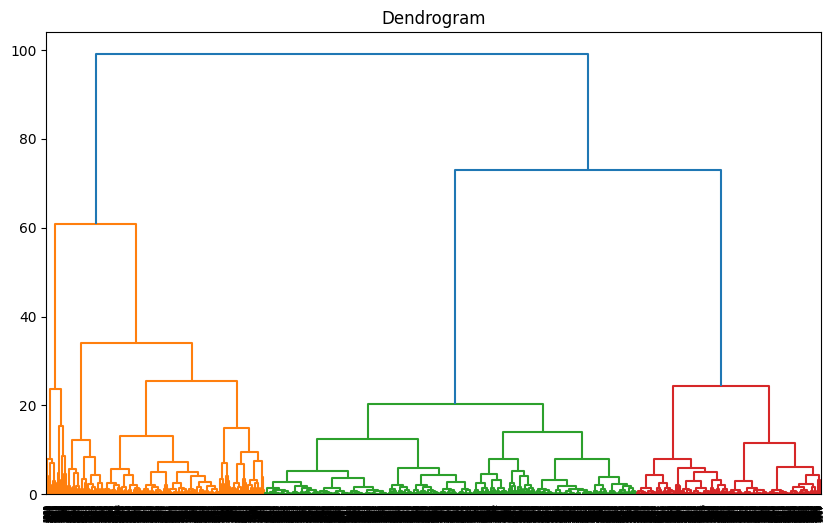

In [32]:
linked = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

## DBSCAN

In [33]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(rfm_scaled)

In [34]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [35]:
results = []

models = {
    "KMeans": kmeans_labels,
    "Hierarchical": hierarchical_labels,
    "DBSCAN": dbscan_labels
}

for name, labels in models.items():

    if len(set(labels)) > 1:
        silhouette = silhouette_score(rfm_scaled, labels)
        dbi = davies_bouldin_score(rfm_scaled, labels)
        chi = calinski_harabasz_score(rfm_scaled, labels)
    else:
        silhouette, dbi, chi = None, None, None

    results.append([name, silhouette, dbi, chi])

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Silhouette Score",
    "Davies-Bouldin Index",
    "Calinski-Harabasz Index"
])

results_df

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,KMeans,0.487150,0.769174,4687.478845
1,Hierarchical,0.455499,0.773831,3979.338617
2,DBSCAN,0.629420,2.270560,488.492257


## Predictive Modeling

### Create Target Variable

In [36]:
rfm['HighValue'] = np.where(rfm['Monetary'] > rfm['Monetary'].median(), 1, 0)

In [37]:
rfm.head()

,Monetary,Frequency,Recency,HighValue
CustomerID,,,,
12347.0,4310.00,7,2,1
12348.0,1797.24,4,75,1
12349.0,1757.55,1,19,1
12350.0,334.40,1,310,0
12352.0,2506.04,8,36,1


## Train-Test Split

In [38]:
X = rfm[['Recency', 'Frequency', 'Monetary',]]
y = rfm['HighValue']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic Regression

In [40]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.0
RMSE: 0.0
R2: 1.0


## Train Random Forest

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [53]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## SVM

In [51]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

## Gradient Boosting

In [52]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

## Function to calculate metrics

In [54]:
def get_metrics(y_true, y_pred):
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return acc, prec, rec, f1

## Calculate results

In [55]:
rf_results = get_metrics(y_test, rf_pred)
svm_results = get_metrics(y_test, svm_pred)
gb_results = get_metrics(y_test, gb_pred)

## Performance summary table

In [56]:
results = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "Gradient Boosting"],
    "Accuracy": [rf_results[0], svm_results[0], gb_results[0]],
    "Precision": [rf_results[1], svm_results[1], gb_results[1]],
    "Recall": [rf_results[2], svm_results[2], gb_results[2]],
    "F1 Score": [rf_results[3], svm_results[3], gb_results[3]]
})

print(results)

               Model  Accuracy  Precision    Recall  F1 Score
0      Random Forest  1.000000   1.000000  1.000000  1.000000
1                SVM  0.992966   0.993065  0.992966  0.992966
2  Gradient Boosting  1.000000   1.000000  1.000000  1.000000


## Confusion matrix example (SVM)

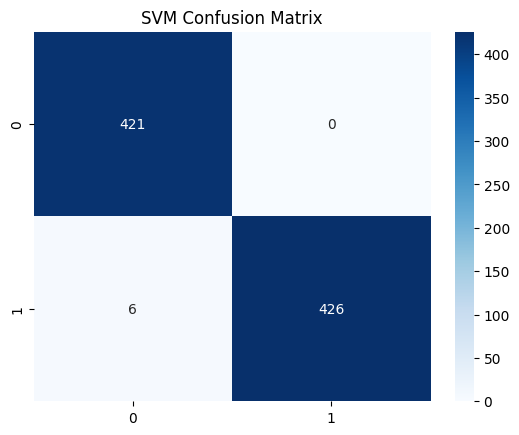

In [58]:
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

## Save Models for Steamlit

In [59]:
joblib.dump(kmeans, "Customer_segmentation_model.pkl")
joblib.dump(model.predict, "Customer_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']